In [39]:
import pandas as pd
import io
import numpy as np

df = pd.read_csv('../../Data/Survival_HNSCC_CP.csv')

date_cols = [
    'Consent', '1st dose IO', 'Date of Surgery', 'Last Date of IO', 
    'Date of Last Follow-up', 'Last Known Alive', 'Date of Death', 'Date of Recurrence'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df['os_event'] = df['Survival Status'].apply(lambda x: 1 if x in ['DOD', 'DOC'] else 0)

df['dfs_event'] = np.where(df['Date of Recurrence'].notna(), 1, 0)

def calculate_months(start, end):
    if pd.isna(start) or pd.isna(end):
        return np.nan
    return (end - start).days / 30.44

df['Overall Months'] = df.apply(
    lambda x: x['Overall Months'] if pd.notna(x['Overall Months']) 
    else calculate_months(x['Date of Surgery'], x['Last Known Alive']), axis=1
)

binary_map = {'Yes': 1, 'No': 0}
df['Tumor Bed'] = df['Tumor Bed'].map(binary_map)
df['Neck mets'] = df['Neck mets'].map(binary_map)

# 5. Clean whitespace in strings
df['Survival Status'] = df['Survival Status'].str.strip()

df.to_csv('../../Data/Cleaned_Survival_HNSCC_CP.csv', index=False)

print("Data cleaning complete. 'os_event' and 'dfs_event' added.")
print(df[['Subject ID', 'Overall Months', 'os_event', 'dfs_event']].head())

Data cleaning complete. 'os_event' and 'dfs_event' added.
    Subject ID  Overall Months  os_event  dfs_event
0  HN2001-0101           41.59         1          1
1  HN2001-0102           50.82         0          1
2  HN2001-0103           23.13         1          1
3  HN2001-0107           13.01         0          0
4  HN2001-0201           48.75         0          1


/tmp/ipykernel_1383975/2713712683.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
/tmp/ipykernel_1383975/2713712683.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
/tmp/ipykernel_1383975/2713712683.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
/tmp/ipykernel_1383975/2713712683.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsi

In [40]:
df = pd.read_csv('../../Data/Cleaned_Survival_HNSCC_CP.csv')
df['Disease Free Months'] = df['Disease Free Months'].fillna(df['Overall Months'])
os_survival_data = df[["Overall Months", "os_event"]]
dfs_survival_data = df[["Disease Free Months", "dfs_event"]]

/tmp/ipykernel_1383975/1298360961.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.0%}'.format(x) for x in vals])


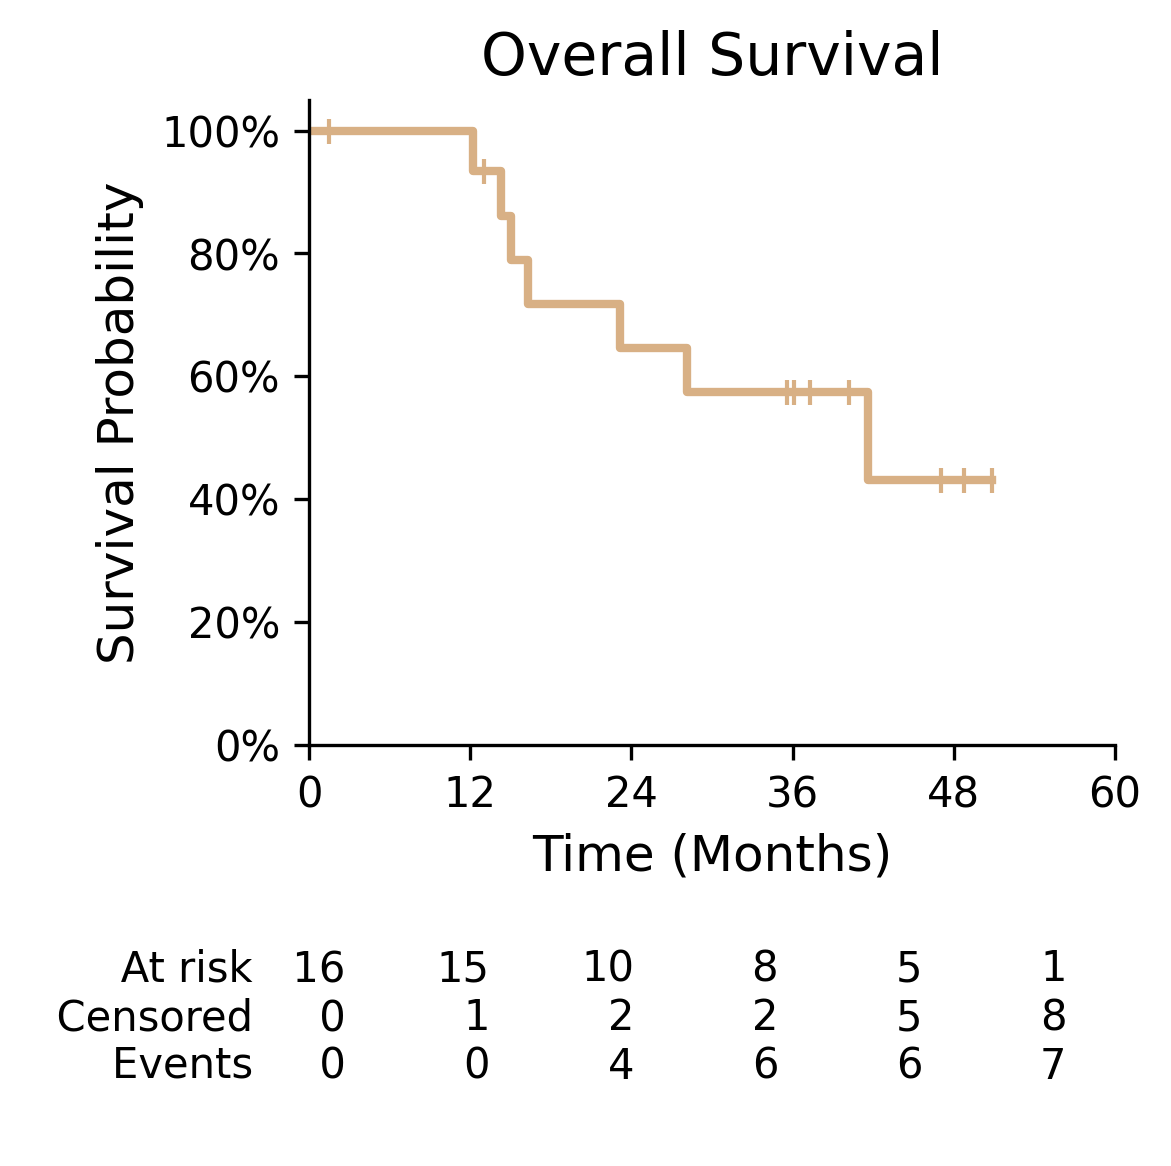

In [43]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

df = os_survival_data

durations = df['Overall Months']
event_observed = df['os_event']

kmf = KaplanMeierFitter()
kmf.fit(durations, event_observed, label="")

fig, ax = plt.subplots(figsize=(4, 4), dpi=300)

custom_ticks = [0, 12, 24, 36, 48, 60]

kmf.plot_survival_function(ax=ax, 
                           at_risk_counts=True, 
                           color='#D8B085',
                           linewidth=2,
                           show_censors=True,
                           ci_show=False,
                           legend=False,
                           censor_styles={'ms': 6, 'marker': '|'})

ax.set_xticks(custom_ticks)
ax.set_xlim([0, 60])

ax.set_title('Overall Survival', fontsize=14)
ax.set_xlabel('Time (Months)', fontsize=12)
ax.set_ylabel('Survival Probability', fontsize=12)
ax.set_ylim([0, 1.05])
ax.grid(False)

vals = ax.get_yticks()
ax.set_yticklabels(['{:,.0%}'.format(x) for x in vals])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('OS.pdf')

/tmp/ipykernel_1383975/2096450240.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.0%}'.format(x) for x in vals])


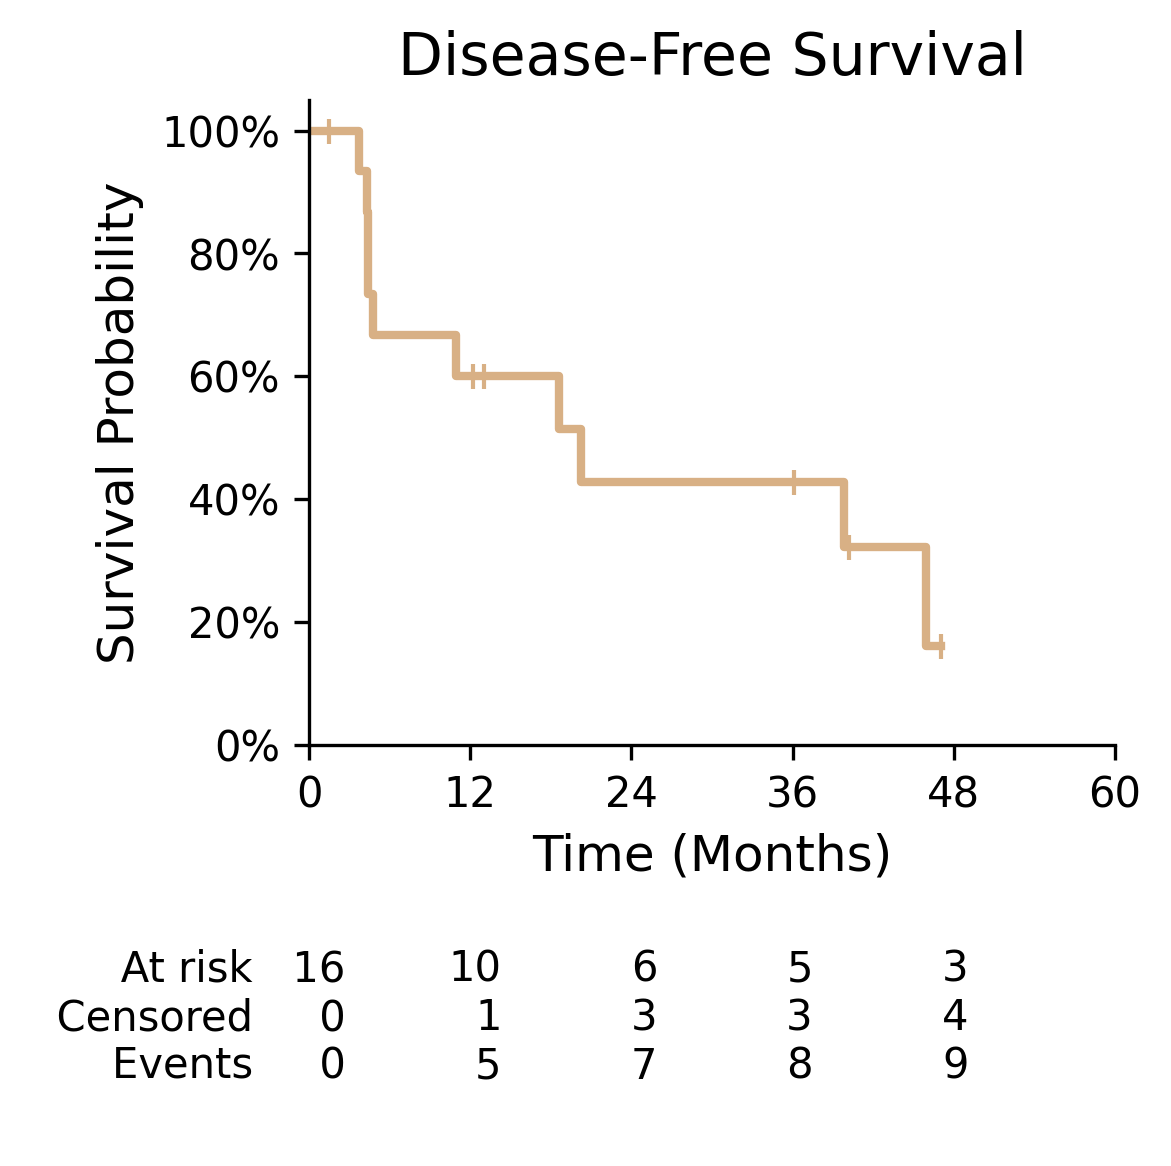

In [45]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

df = dfs_survival_data

durations = df['Disease Free Months']
event_observed = df['dfs_event']

kmf = KaplanMeierFitter()
kmf.fit(durations, event_observed, label="")

fig, ax = plt.subplots(figsize=(4, 4), dpi=300)

custom_ticks = [0, 12, 24, 36, 48, 60]

kmf.plot_survival_function(ax=ax, 
                           at_risk_counts=True, 
                           color='#D8B085',
                           linewidth=2,
                           show_censors=True,
                           ci_show=False,
                           legend=False,
                           censor_styles={'ms': 6, 'marker': '|'})

ax.set_xticks(custom_ticks)
ax.set_xlim([0, 60])

ax.set_title('Disease-Free Survival', fontsize=14)
ax.set_xlabel('Time (Months)', fontsize=12)
ax.set_ylabel('Survival Probability', fontsize=12)
ax.set_ylim([0, 1.05])
ax.grid(False)

vals = ax.get_yticks()
ax.set_yticklabels(['{:,.0%}'.format(x) for x in vals])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('DFS.pdf')